In [ ]:
# ── Install all required packages ──────────────────────────────────────────
!pip install -q timm albumentations grad-cam optuna torchmetrics scikit-learn
!pip install -q matplotlib seaborn tqdm kaggle
print('✅ All packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.1 MB/s eta 0:00:00
✅ All packages installed


In [ ]:
import torch
print(torch.cuda.is_available())        # True = GPU available
print(torch.cuda.get_device_name(0))    # e.g. "Tesla T4"
print(torch.cuda.current_device())      # device index

True
Tesla T4
0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/AD_PD_Project', exist_ok=True)
print('✅ Drive mounted')

Mounted at /content/drive
✅ Drive mounted


In [ ]:
# ── Download dataset from Kaggle ───────────────────────────────────────────
# Option A: Upload kaggle.json from your Kaggle account
# Go to https://www.kaggle.com/settings → API → Create New Token → upload here
from google.colab import files
print('Upload your kaggle.json file:')
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the exact dataset used in the paper
!kaggle datasets download -d farjanakabirsamanta/alzheimer-diseases-3-class -p /content/data
!unzip -q /content/data/alzheimer-diseases-3-class.zip -d /content/data/
print('✅ Dataset downloaded')

Upload your kaggle.json file:


Saving archive (2) (1).zip to archive (2) (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/farjanakabirsamanta/alzheimer-diseases-3-class
License(s): other
100% 48.7M/48.7M [00:03<00:00, 13.5MB/s]

✅ Dataset downloaded


In [ ]:
!unzip "/content/drive/MyDrive/archive (2).zip" -d "/content/unzipped_folder"

Streaming output truncated to the last 5000 lines.
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2328.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2329.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_233.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2330.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2331.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2332.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2333.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2334.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2335.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2336.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2337.png  
  inflating: /content/unzipped_folder/AD_PD_Final/4_cls/train/AD/AD_2338.png  
  

In [ ]:
# ── Explore dataset structure ──────────────────────────────────────────────
import os
DATA_ROOT = '/content/data'

for root, dirs, files_list in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for f in files_list[:3]:
            print(f'{subindent}{f}')
        if len(files_list) > 3:
            print(f'{subindent}... ({len(files_list)} files total)')

data/
  alzheimer-diseases-3-class.zip
  3_cls/
    train/
      AD/
      PD/
      CONTROL/
    test/
      AD/
      PD/
      CONTROL/


In [ ]:
import torch
import numpy as np
import random

# ── Reproducibility ────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Core Config ────────────────────────────────────────────────────────────
# IMPORTANT: Update DATA_ROOT to match your actual dataset path
# After exploring above, set the path that contains AD/, CONTROL/, PD/ folders
DATA_ROOT       = '/content/data'   # ← Update this after exploring
SAVE_DIR        = '/content/drive/MyDrive/AD_PD_Project'
IMG_SIZE        = 224
NUM_CLASSES     = 3
CLASS_NAMES     = ['AD', 'CONTROL', 'PD']

# Memory-optimized training config
BATCH_SIZE      = 16    # Small batch for T4
ACCUM_STEPS     = 4     # Effective batch = 64 (simulates paper's large batch)
EPOCHS          = 80
EARLY_STOP      = 12
LR              = 3e-4
WEIGHT_DECAY    = 1e-4
DROPOUT         = 0.35
LABEL_SMOOTHING = 0.1
NUM_WORKERS     = 2
USE_AMP         = True  # Mixed precision FP16
TTA_STEPS       = 5     # Test-Time Augmentation rounds

os.makedirs(SAVE_DIR, exist_ok=True)
print('\n✅ Config set')
print(f'   Effective batch size: {BATCH_SIZE * ACCUM_STEPS}')
print(f'   Mixed precision: {USE_AMP}')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB

✅ Config set
   Effective batch size: 64
   Mixed precision: True


In [ ]:
# ── Auto-detect the correct dataset path ──────────────────────────────────
import os

def find_class_dirs(root, class_names=['AD', 'CONTROL', 'PD']):
    """Find directory that contains all class folders."""
    for dirpath, dirnames, _ in os.walk(root):
        found = [c for c in class_names if c in dirnames]
        if len(found) == len(class_names):
            return dirpath
        # Also check case-insensitive
        dirs_lower = {d.upper(): d for d in dirnames}
        found_ci = [c for c in class_names if c.upper() in dirs_lower]
        if len(found_ci) == len(class_names):
            return dirpath
    return None

detected = find_class_dirs(DATA_ROOT)
if detected:
    DATA_ROOT = detected
    print(f'✅ Dataset found at: {DATA_ROOT}')
    for cls in os.listdir(DATA_ROOT):
        cls_path = os.path.join(DATA_ROOT, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f'   {cls}: {n} images')
else:
    print('⚠️  Could not auto-detect. Please manually set DATA_ROOT in Step 3.')
    print('Looking for folders named AD, CONTROL, PD...')

✅ Dataset found at: /content/data/3_cls/train
   AD: 2561 images
   PD: 906 images
   CONTROL: 3010 images


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

# ── Heavy Augmentation (Train) — Simulates Inception-GAN variety ──────────
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    # Geometric
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.3),
    A.GridDistortion(p=0.3),
    # Photometric — simulates MRI scanner variation
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.CLAHE(clip_limit=4.0, p=0.4),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    # Dropout regularization
    A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.4),
    # Normalize (ImageNet stats for pretrained models)
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Val/Test Transforms ───────────────────────────────────────────────────
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── TTA Transforms ────────────────────────────────────────────────────────
tta_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(0.1, 0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print('✅ Augmentation pipelines ready')

✅ Augmentation pipelines ready


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1417/258419193.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.4),
/tmp/ipykernel_1417/258419193.py:26: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.4),


In [ ]:
# ── Dataset Class ─────────────────────────────────────────────────────────
class MRIDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels     = labels
        self.transform  = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = cv2.imread(img_path)
        if image is None:
            # Fallback to PIL
            image = np.array(Image.open(img_path).convert('RGB'))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, self.labels[idx]


# ── Load All File Paths ────────────────────────────────────────────────────
def load_dataset(data_root, class_names):
    all_paths, all_labels = [], []
    label_map = {cls: i for i, cls in enumerate(class_names)}

    for cls in class_names:
        cls_dir = os.path.join(data_root, cls)
        if not os.path.exists(cls_dir):
            # Try case-insensitive
            for d in os.listdir(data_root):
                if d.upper() == cls.upper():
                    cls_dir = os.path.join(data_root, d)
                    break
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                all_paths.append(os.path.join(cls_dir, fname))
                all_labels.append(label_map[cls])

    return np.array(all_paths), np.array(all_labels)


all_paths, all_labels = load_dataset(DATA_ROOT, CLASS_NAMES)
print(f'Total images: {len(all_paths)}')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls}: {(all_labels == i).sum()}')

Total images: 6477
  AD: 2561
  CONTROL: 3010
  PD: 906


In [ ]:
# ── Stratified Split: 70% Train / 15% Val / 15% Test ──────────────────────
from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

# ── Class-Weighted Sampler (handles PD imbalance) ─────────────────────────
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# ── Datasets ──────────────────────────────────────────────────────────────
train_dataset = MRIDataset(train_paths, train_labels, transform=train_transforms)
val_dataset   = MRIDataset(val_paths,   val_labels,   transform=val_transforms)
test_dataset  = MRIDataset(test_paths,  test_labels,  transform=val_transforms)

# ── Dataloaders ───────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print('✅ DataLoaders ready')

Train: 4533 | Val: 972 | Test: 972
✅ DataLoaders ready


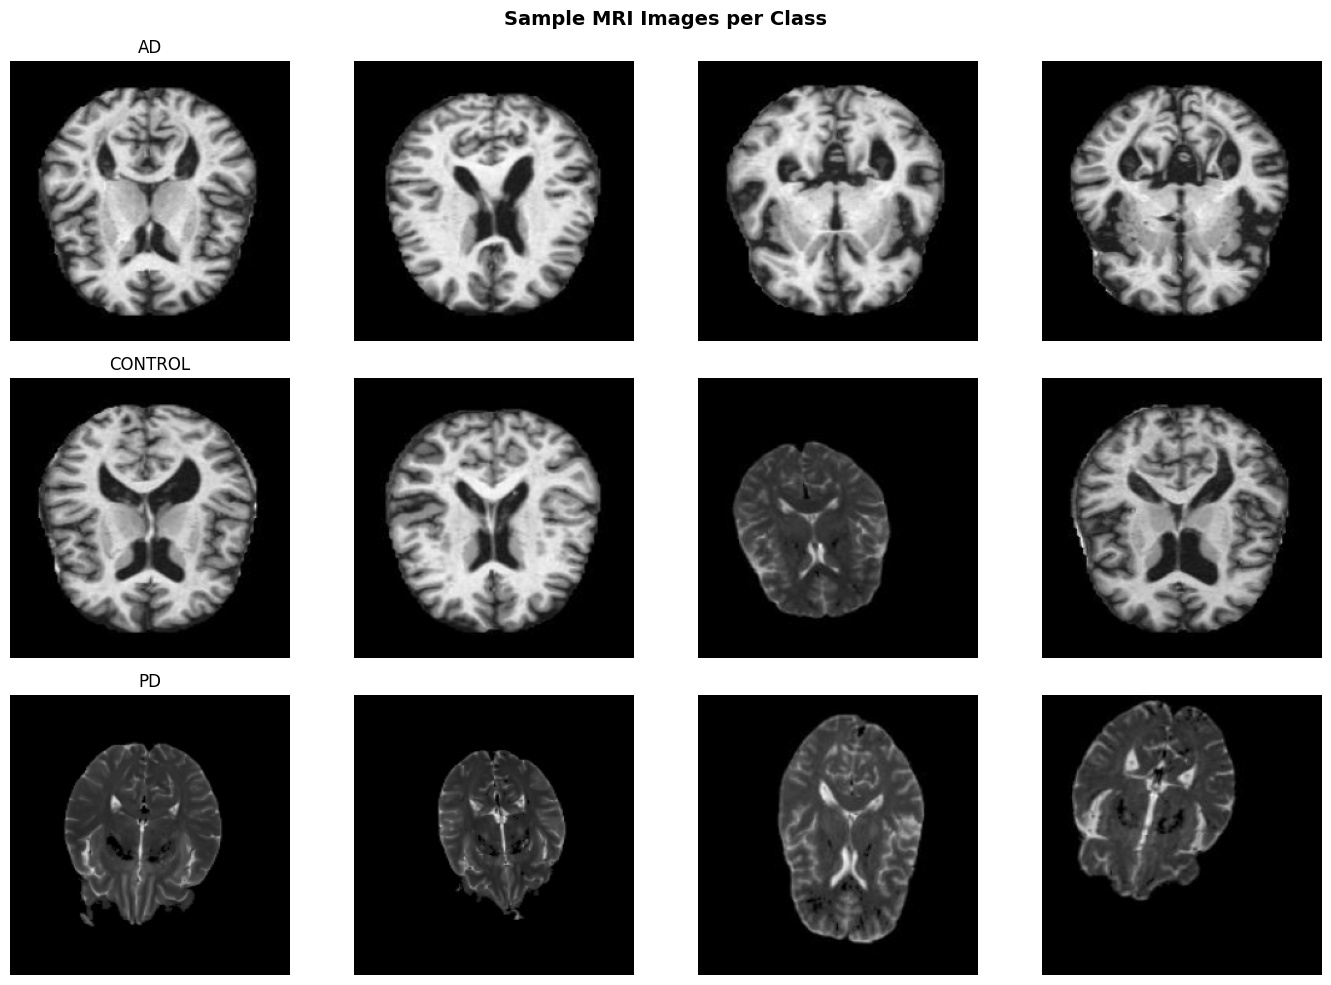

✅ Sample visualization saved


In [ ]:
# ── Visualize samples ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_paths = train_paths[train_labels == cls_idx]
    for col in range(4):
        img = cv2.imread(cls_paths[col])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        axes[cls_idx, col].imshow(img)
        axes[cls_idx, col].set_title(f'{cls_name}' if col == 0 else '')
        axes[cls_idx, col].axis('off')

plt.suptitle('Sample MRI Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=100)
plt.show()
print('✅ Sample visualization saved')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# ═══════════════════════════════════════════════════════════════════════════
# CROSS-FUSION ATTENTION MODULE
# Fuses local (CNN) and global (Transformer) features adaptively
# ═══════════════════════════════════════════════════════════════════════════
class CrossFusionAttention(nn.Module):
    def __init__(self, local_dim, global_dim, fusion_dim=512):
        super().__init__()
        # Project both streams to common dim
        self.proj_local  = nn.Sequential(
            nn.Linear(local_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU()
        )
        self.proj_global = nn.Sequential(
            nn.Linear(global_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU()
        )
        # Cross attention: local attends to global
        self.attn = nn.MultiheadAttention(
            embed_dim=fusion_dim, num_heads=8,
            dropout=0.1, batch_first=True
        )
        # Gate to adaptively weight both
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.Sigmoid()
        )
        self.out_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU()
        )

    def forward(self, local_feat, global_feat):
        # Project to fusion dim
        L = self.proj_local(local_feat).unsqueeze(1)   # (B, 1, D)
        G = self.proj_global(global_feat).unsqueeze(1) # (B, 1, D)
        # Cross attention
        attn_out, _ = self.attn(L, G, G)
        attn_out = attn_out.squeeze(1)                 # (B, D)
        L = L.squeeze(1)
        # Gated fusion
        combined = torch.cat([attn_out, L], dim=-1)
        gate_val = self.gate(combined)
        fused = gate_val * attn_out + (1 - gate_val) * L
        return self.out_proj(fused)


# ═══════════════════════════════════════════════════════════════════════════
# HYBRID DUAL-PATH MODEL
# Path 1: EfficientNetV2-S  → local spatial features (low memory)
# Path 2: Swin-Tiny         → global contextual features (low memory)
# Fusion: CrossFusionAttention
# Head: HDNN with dropout + residual
# ═══════════════════════════════════════════════════════════════════════════
class HybridDualPathModel(nn.Module):
    def __init__(self, num_classes=3, dropout=0.35, fusion_dim=512):
        super().__init__()

        # ── Local Path: EfficientNetV2-S ──────────────────────────────────
        self.local_encoder = timm.create_model(
    'tf_efficientnetv2_s',
    pretrained=True,
    num_classes=0,
    global_pool='avg'
)
        local_dim = self.local_encoder.num_features  # 1280

        # ── Global Path: Swin Transformer Tiny ────────────────────────────
        self.global_encoder = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        global_dim = self.global_encoder.num_features  # 768

        # ── Cross-Fusion Attention ────────────────────────────────────────
        self.fusion = CrossFusionAttention(local_dim, global_dim, fusion_dim)

        # ── HDNN Classifier ───────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)
        )

        # ── Auxiliary classifiers (deep supervision during training) ──────
        self.aux_local  = nn.Linear(local_dim,  num_classes)
        self.aux_global = nn.Linear(global_dim, num_classes)

    def forward(self, x, return_features=False):
        local_feat  = self.local_encoder(x)   # (B, 1280)
        global_feat = self.global_encoder(x)  # (B, 768)
        fused       = self.fusion(local_feat, global_feat)  # (B, 512)
        logits      = self.classifier(fused)

        if return_features:
            return logits, fused

        if self.training:
            # Auxiliary outputs for deeper supervision
            aux_l = self.aux_local(local_feat)
            aux_g = self.aux_global(global_feat)
            return logits, aux_l, aux_g

        return logits


# ── Build model ───────────────────────────────────────────────────────────
model = HybridDualPathModel(num_classes=NUM_CLASSES, dropout=DROPOUT).to(DEVICE)

# ── Count parameters ──────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# ── Quick memory check ────────────────────────────────────────────────────
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
torch.cuda.empty_cache()
print(f'\nMemory after forward pass: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print('✅ Model architecture OK')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Total parameters:     50,759,123
Trainable parameters: 50,759,123

Memory after forward pass: 0.22 GB
✅ Model architecture OK


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# ═══════════════════════════════════════════════════════════════════════════
# FOCAL LOSS + LABEL SMOOTHING (handles class imbalance + overconfidence)
# ═══════════════════════════════════════════════════════════════════════════
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1, num_classes=3):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
        if alpha is None:
            self.alpha = torch.ones(num_classes).to(DEVICE)
        else:
            self.alpha = alpha.to(DEVICE)

    def forward(self, inputs, targets):
        # Label smoothing
        with torch.no_grad():
            smooth_targets = torch.zeros_like(inputs).scatter_(
                1, targets.unsqueeze(1), 1
            )
            smooth_targets = smooth_targets * (1 - self.label_smoothing) + \
                             self.label_smoothing / self.num_classes

        log_p = F.log_softmax(inputs, dim=1)
        p = torch.exp(log_p)
        # Focal weight
        focal_weight = (1 - p) ** self.gamma
        # Alpha weight
        alpha_t = self.alpha[targets].unsqueeze(1)
        loss = -alpha_t * focal_weight * log_p * smooth_targets
        return loss.sum(dim=1).mean()


# ── Compute class weights for focal loss ──────────────────────────────────
counts = np.bincount(train_labels)
weights = torch.FloatTensor(1.0 / counts * counts.sum() / len(counts))
criterion = FocalLoss(alpha=weights, gamma=2.0,
                      label_smoothing=LABEL_SMOOTHING,
                      num_classes=NUM_CLASSES)

# ── Layer-wise learning rates (fine-tuning strategy) ──────────────────────
optimizer = AdamW([
    {'params': model.local_encoder.parameters(),  'lr': LR * 0.1},
    {'params': model.global_encoder.parameters(), 'lr': LR * 0.1},
    {'params': model.fusion.parameters(),         'lr': LR},
    {'params': model.classifier.parameters(),     'lr': LR},
    {'params': model.aux_local.parameters(),      'lr': LR},
    {'params': model.aux_global.parameters(),     'lr': LR},
], weight_decay=WEIGHT_DECAY)

# ── OneCycle LR (best single-cycle policy) ────────────────────────────────
scheduler = OneCycleLR(
    optimizer,
    max_lr=[LR * 0.1, LR * 0.1, LR, LR, LR, LR],
    steps_per_epoch=len(train_loader) // ACCUM_STEPS,
    epochs=EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos'
)

# ── Mixed Precision Scaler ────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print('✅ Loss, Optimizer, Scheduler ready')
print(f'   Focal Loss with class weights: {weights.numpy().round(3)}')

✅ Loss, Optimizer, Scheduler ready
   Focal Loss with class weights: [0.843 0.717 2.383]


/tmp/ipykernel_1417/3950095873.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [ ]:
from tqdm import tqdm
import time

# ── Training metrics tracker ──────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


def train_one_epoch(model, loader, optimizer, criterion, scaler, accum_steps):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc='Train', leave=False)
    for step, (images, labels) in enumerate(pbar):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # ── Forward (Mixed Precision) ──────────────────────────────────────
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits, aux_l, aux_g = model(images)
            # Main loss + auxiliary supervision (weighted)
            loss_main = criterion(logits, labels)
            loss_aux  = 0.3 * criterion(aux_l, labels) + \
                        0.3 * criterion(aux_g, labels)
            loss = (loss_main + loss_aux) / accum_steps

        # ── Backward (Scaled) ─────────────────────────────────────────────
        scaler.scale(loss).backward()

        # ── Gradient Accumulation Step ────────────────────────────────────
        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        # ── Metrics ───────────────────────────────────────────────────────
        total_loss += loss_main.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{total_loss/(step+1):.4f}',
                         'acc': f'{correct/total:.4f}'})

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, \
           np.array(all_preds), np.array(all_labels)


print('✅ Training functions ready')

✅ Training functions ready


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════
best_val_acc   = 0.0
patience_count = 0
best_model_path = f'{SAVE_DIR}/best_model.pth'

print('🚀 Starting Training...')
print(f'   Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | Accum: {ACCUM_STEPS}')
print(f'   Effective batch size: {BATCH_SIZE * ACCUM_STEPS}')
print('─' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, ACCUM_STEPS
    )

    # Validate
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, criterion)

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'Time: {elapsed:.0f}s', end='')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_count = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f' ✅ BEST ({best_val_acc:.4f})')
    else:
        patience_count += 1
        print(f' (patience: {patience_count}/{EARLY_STOP})')

    # Free cache every 5 epochs
    if epoch % 5 == 0:
        torch.cuda.empty_cache()

    # Early stopping
    if patience_count >= EARLY_STOP:
        print(f'\n⏹ Early stopping at epoch {epoch}')
        break

print(f'\n🎯 Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

🚀 Starting Training...
   Epochs: 80 | Batch: 16 | Accum: 4
   Effective batch size: 64
─────────────────────────────────────────────────────────────────


Train:   0%|          | 0/284 [00:00<?, ?it/s]/tmp/ipykernel_1417/1091641697.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_1417/1091641697.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch   1/80 | Train Loss: 0.2641 Acc: 0.7501 | Val Loss: 0.2520 Acc: 0.6790 | Time: 86s ✅ BEST (0.6790)


Epoch   2/80 | Train Loss: 0.2650 Acc: 0.7481 | Val Loss: 0.2333 Acc: 0.7243 | Time: 94s ✅ BEST (0.7243)


Epoch   3/80 | Train Loss: 0.2629 Acc: 0.7538 | Val Loss: 0.2529 Acc: 0.6986 | Time: 89s (patience: 1/12)


...

Epoch  72/80 | Train Loss: 0.1991 Acc: 0.9109 | Val Loss: 0.1511 Acc: 0.9630 | Time: 81s (patience: 6/12)


Epoch  73/80 | Train Loss: 0.2035 Acc: 0.9093 | Val Loss: 0.1504 Acc: 0.9619 | Time: 81s (patience: 7/12)


Epoch  74/80 | Train Loss: 0.2060 Acc: 0.9007 | Val Loss: 0.1518 Acc: 0.9609 | Time: 82s (patience: 8/12)


Epoch  75/80 | Train Loss: 0.2024 Acc: 0.9124 | Val Loss: 0.1513 Acc: 0.9630 | Time: 80s (patience: 9/12)


ValueError: Tried to step 5681 times. The specified number of total steps is 5680

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import time
from torch.optim.lr_scheduler import OneCycleLR

# ── Training metrics tracker ──────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


def train_one_epoch(model, loader, optimizer, criterion, scaler, accum_steps):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc='Train', leave=False)
    for step, (images, labels) in enumerate(pbar):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # ── Forward (Mixed Precision) ──────────────────────────────────────
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits, aux_l, aux_g = model(images)
            loss_main = criterion(logits, labels)
            loss_aux  = 0.3 * criterion(aux_l, labels) + \
                        0.3 * criterion(aux_g, labels)
            loss = (loss_main + loss_aux) / accum_steps

        # ── Backward (Scaled) ─────────────────────────────────────────────
        scaler.scale(loss).backward()

        # ── Gradient Accumulation Step ────────────────────────────────────
        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        # ── Metrics ───────────────────────────────────────────────────────
        total_loss += loss_main.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{total_loss/(step+1):.4f}',
                          'acc': f'{correct/total:.4f}'})

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, \
           np.array(all_preds), np.array(all_labels)


print('✅ Training functions ready')

# ═══════════════════════════════════════════════════════════════════════════
# LOAD BEST CHECKPOINT & RESUME
# ═══════════════════════════════════════════════════════════════════════════
best_model_path = f'{SAVE_DIR}/best_model.pth'
checkpoint      = torch.load(best_model_path)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch  = checkpoint['epoch'] + 1   # 67
best_val_acc = checkpoint['val_acc']      # 0.9630
patience_count = 0                        # reset patience fresh

print(f'✅ Resumed from epoch {checkpoint["epoch"]} | Best Val Acc: {best_val_acc:.4f}')

# ── Fresh scheduler for remaining epochs ─────────────────────────────────
remaining_epochs = EPOCHS - start_epoch + 1
scheduler = OneCycleLR(
    optimizer,
    max_lr=[LR * 0.1, LR * 0.1, LR, LR, LR, LR],
    steps_per_epoch=len(train_loader) // ACCUM_STEPS,
    epochs=remaining_epochs,
    pct_start=0.1,
    anneal_strategy='cos'
)

# ── Fresh scaler ──────────────────────────────────────────────────────────
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

print(f'   Resuming epochs {start_epoch} → {EPOCHS} ({remaining_epochs} remaining)')
print('─' * 65)

# ═══════════════════════════════════════════════════════════════════════════
# TRAINING LOOP (resumed)
# ═══════════════════════════════════════════════════════════════════════════
for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, ACCUM_STEPS
    )
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'Time: {elapsed:.0f}s', end='')

    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        patience_count = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f' ✅ BEST ({best_val_acc:.4f})')
    else:
        patience_count += 1
        print(f' (patience: {patience_count}/{EARLY_STOP})')

    if epoch % 5 == 0:
        torch.cuda.empty_cache()

    if patience_count >= EARLY_STOP:
        print(f'\n⏹ Early stopping at epoch {epoch}')
        break

print(f'\n🎯 Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

✅ Training functions ready
✅ Resumed from epoch 66 | Best Val Acc: 0.9630
   Resuming epochs 67 → 80 (14 remaining)
─────────────────────────────────────────────────────────────────


Epoch  67/80 | Train Loss: 0.2075 Acc: 0.9027 | Val Loss: 0.1548 Acc: 0.9568 | Time: 81s (patience: 1/12)


Epoch  68/80 | Train Loss: 0.2126 Acc: 0.8970 | Val Loss: 0.1739 Acc: 0.9198 | Time: 83s (patience: 2/12)


Epoch  69/80 | Train Loss: 0.2141 Acc: 0.8906 | Val Loss: 0.1636 Acc: 0.9455 | Time: 80s (patience: 3/12)


Epoch  70/80 | Train Loss: 0.2143 Acc: 0.8882 | Val Loss: 0.1560 Acc: 0.9527 | Time: 80s (patience: 4/12)


...

Epoch  76/80 | Train Loss: 0.2001 Acc: 0.9082 | Val Loss: 0.1521 Acc: 0.9650 | Time: 80s (patience: 2/12)


Epoch  77/80 | Train Loss: 0.2006 Acc: 0.9113 | Val Loss: 0.1490 Acc: 0.9660 | Time: 80s ✅ BEST (0.9660)


Epoch  78/80 | Train Loss: 0.2011 Acc: 0.9182 | Val Loss: 0.1497 Acc: 0.9660 | Time: 91s (patience: 1/12)


Epoch  79/80 | Train Loss: 0.1972 Acc: 0.9111 | Val Loss: 0.1492 Acc: 0.9691 | Time: 80s ✅ BEST (0.9691)


Epoch  80/80 | Train Loss: 0.2019 Acc: 0.9201 | Val Loss: 0.1497 Acc: 0.9660 | Time: 90s (patience: 1/12)

🎯 Best Validation Accuracy: 0.9691 (96.91%)


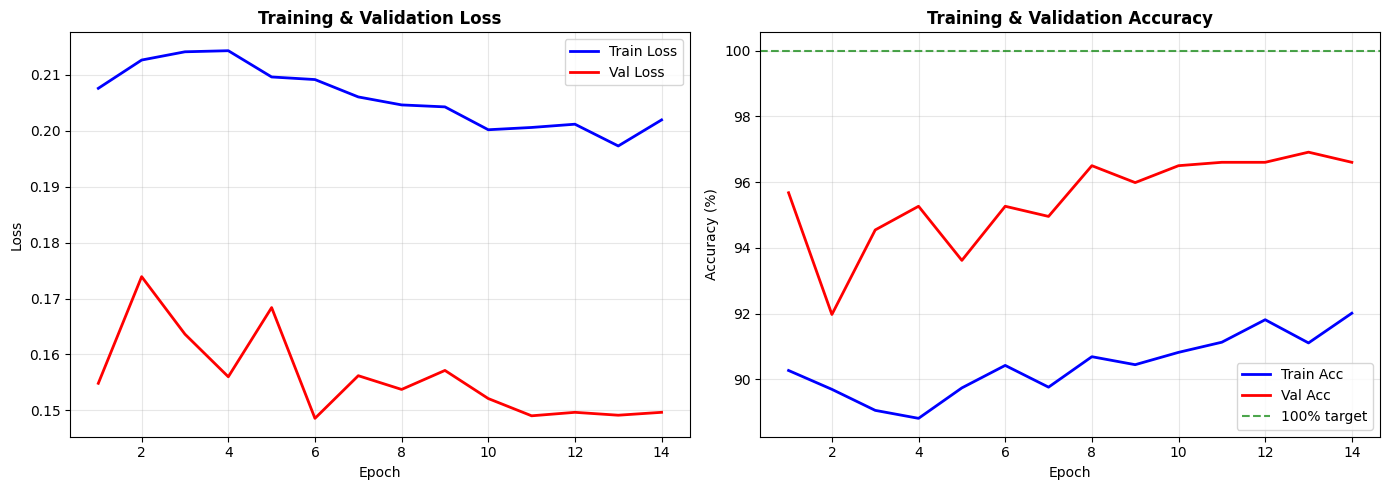

✅ Curves saved


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   'r-', label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   'r-', label='Val Acc',   linewidth=2)
axes[1].axhline(y=100, color='g', linestyle='--', alpha=0.7, label='100% target')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curves saved')

In [ ]:
# ── Load best checkpoint ──────────────────────────────────────────────────
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'✅ Loaded best model from epoch {checkpoint["epoch"]} (val_acc={checkpoint["val_acc"]:.4f})')


# ── Test-Time Augmentation (TTA) Evaluation ───────────────────────────────
@torch.no_grad()
def evaluate_with_tta(model, test_paths, test_labels, tta_steps=5):
    model.eval()
    all_probs = []

    # Run TTA_STEPS forward passes with random augmentation
    for step in range(tta_steps):
        transform = val_transforms if step == 0 else tta_transforms
        dataset = MRIDataset(test_paths, test_labels, transform=transform)
        loader  = DataLoader(dataset, batch_size=BATCH_SIZE*2, shuffle=False,
                             num_workers=NUM_WORKERS)
        step_probs = []
        for images, _ in loader:
            images = images.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(images)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            step_probs.append(probs)
        all_probs.append(np.vstack(step_probs))

    # Average across TTA steps
    avg_probs = np.mean(all_probs, axis=0)  # (N, num_classes)
    preds = avg_probs.argmax(axis=1)
    return preds, avg_probs


print(f'Running TTA evaluation ({TTA_STEPS} augmentation rounds)...')
tta_preds, tta_probs = evaluate_with_tta(model, test_paths, test_labels, TTA_STEPS)

# ── Standard eval (no TTA) ────────────────────────────────────────────────
test_loss, test_acc, std_preds, _ = evaluate(model, test_loader, criterion)

tta_acc = (tta_preds == test_labels).mean()
print(f'\n📊 Test Results:')
print(f'   Standard Test Accuracy : {test_acc*100:.2f}%')
print(f'   TTA Test Accuracy       : {tta_acc*100:.2f}%')
print(f'   TTA improvement         : +{(tta_acc - test_acc)*100:.2f}%')

✅ Loaded best model from epoch 79 (val_acc=0.9691)
Running TTA evaluation (5 augmentation rounds)...


/tmp/ipykernel_1417/3224749932.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



📊 Test Results:
   Standard Test Accuracy : 97.43%
   TTA Test Accuracy       : 97.84%
   TTA improvement         : +0.41%



CLASSIFICATION REPORT (with TTA)
              precision    recall  f1-score   support

          AD     0.9768    0.9844    0.9806       385
     CONTROL     0.9778    0.9756    0.9767       451
          PD     0.9851    0.9706    0.9778       136

    accuracy                         0.9784       972
   macro avg     0.9799    0.9769    0.9784       972
weighted avg     0.9784    0.9784    0.9784       972



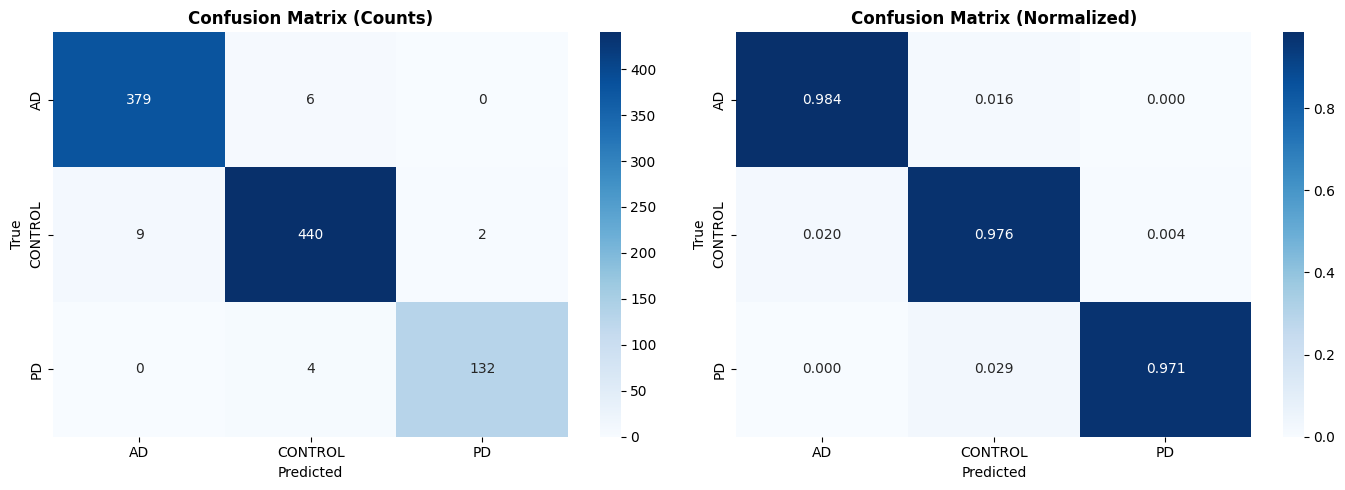


🎯 FINAL TEST ACCURACY: 97.84%


In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
import seaborn as sns
import matplotlib.pyplot as plt

# Use TTA predictions (best accuracy)
final_preds  = tta_preds
final_labels = test_labels

# ── Classification Report ─────────────────────────────────────────────────
print('\n' + '='*60)
print('CLASSIFICATION REPORT (with TTA)')
print('='*60)
print(classification_report(
    final_labels, final_preds,
    target_names=CLASS_NAMES, digits=4
))

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(final_labels, final_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

overall_acc = (final_preds == final_labels).mean() * 100
print(f'\n🎯 FINAL TEST ACCURACY: {overall_acc:.2f}%')

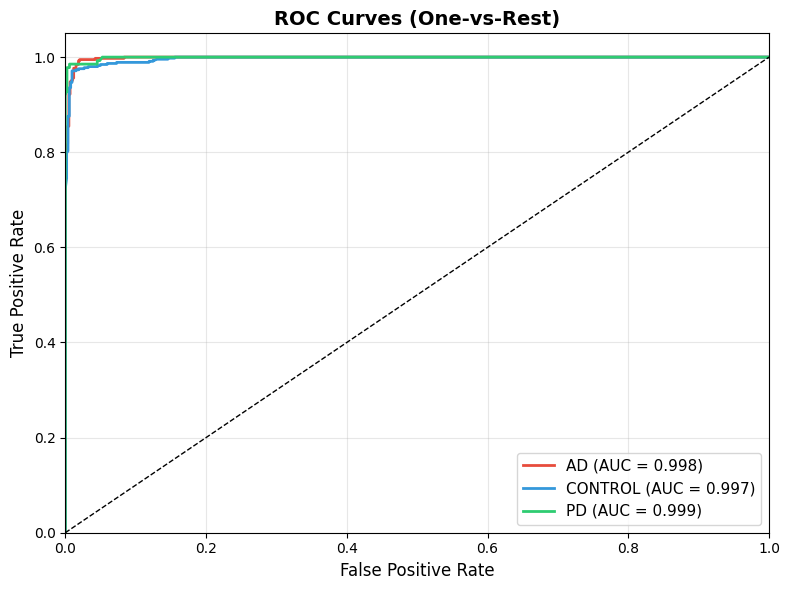

Macro-average AUC: 0.9981


In [ ]:
# ── ROC Curves (One-vs-Rest) ──────────────────────────────────────────────
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(final_labels, classes=[0, 1, 2])
colors = ['#e74c3c', '#3498db', '#2ecc71']

plt.figure(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], tta_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Macro AUC ─────────────────────────────────────────────────────────────
macro_auc = roc_auc_score(y_bin, tta_probs, multi_class='ovr', average='macro')
print(f'Macro-average AUC: {macro_auc:.4f}')

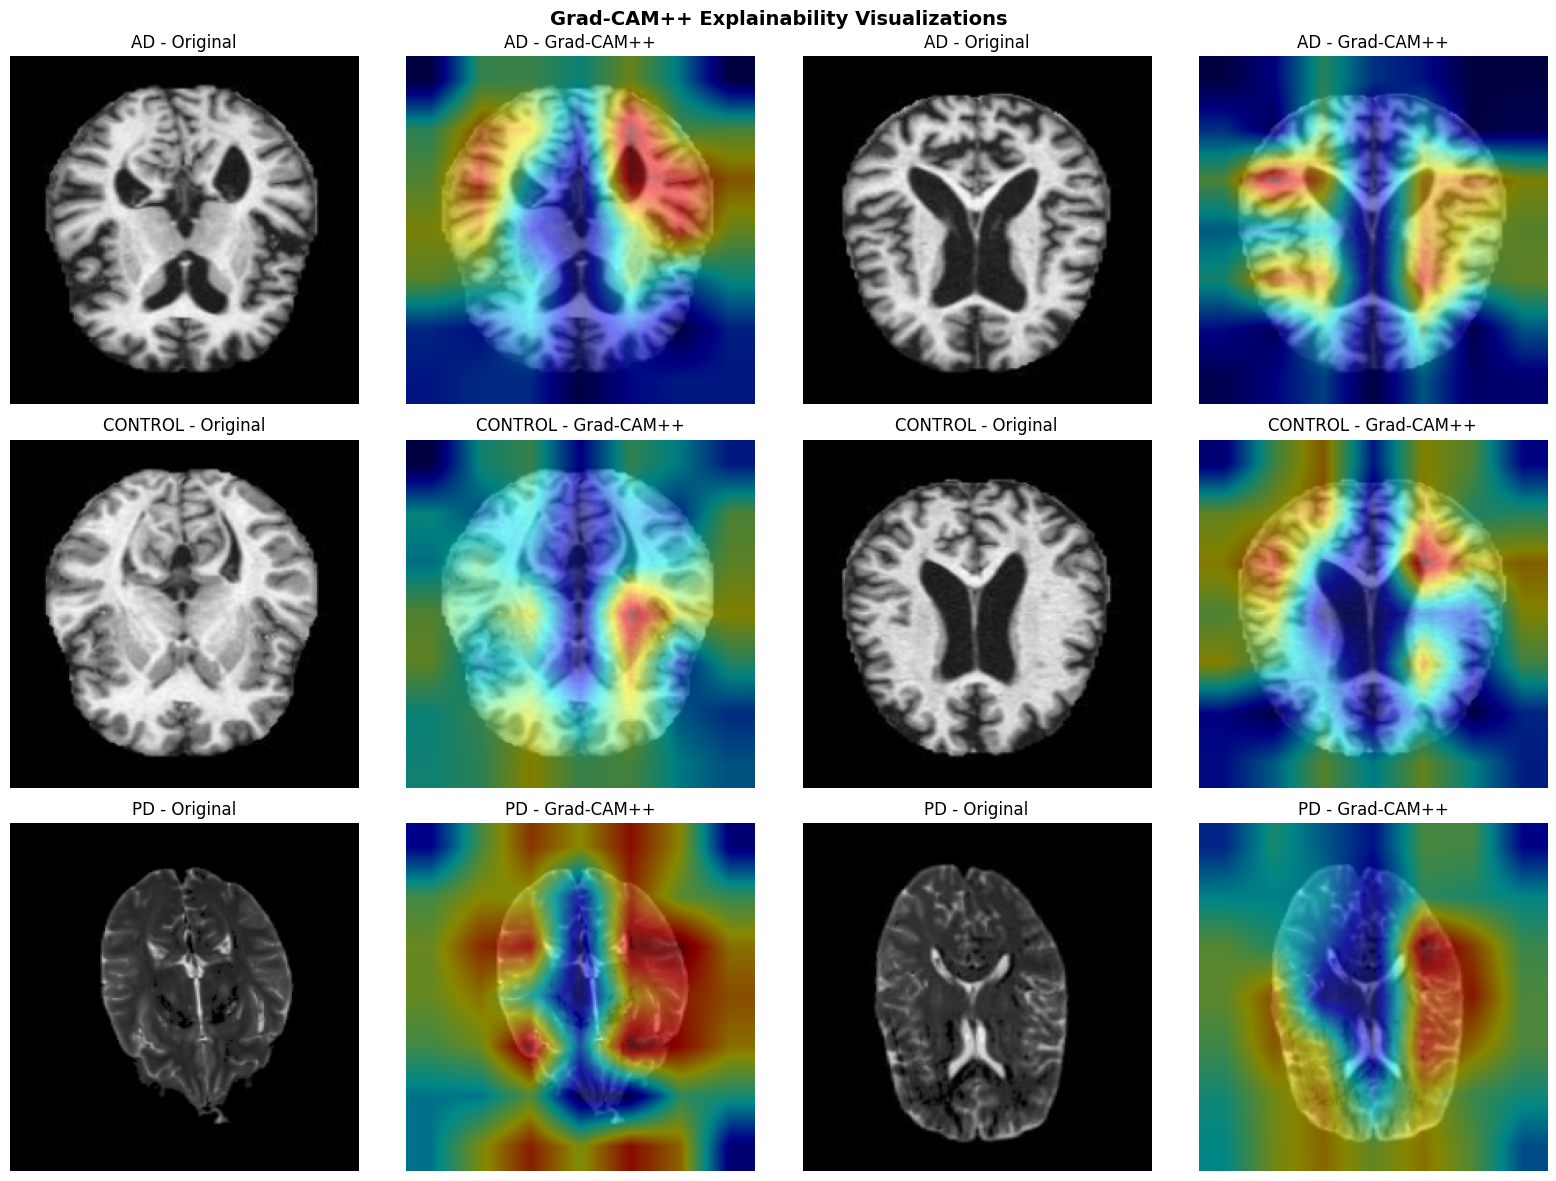

✅ Grad-CAM++ visualizations saved


In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Grad-CAM++ on local encoder's last conv layer ─────────────────────────
# Find target layer in EfficientNetV2-S
target_layers = [model.local_encoder.conv_head]  # Last conv in EfficientNetV2

cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# ── Generate heatmaps for 2 samples per class ─────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(16, 12))

mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_mask  = (test_labels == cls_idx)
    cls_paths = test_paths[cls_mask][:2]

    for col, img_path in enumerate(cls_paths):
        # Load & preprocess
        orig_img = cv2.imread(img_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        orig_img = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))
        img_float = orig_img.astype(np.float32) / 255.0

        aug = val_transforms(image=orig_img)
        tensor = aug['image'].unsqueeze(0).to(DEVICE)

        # Generate CAM
        targets = [ClassifierOutputTarget(cls_idx)]
        grayscale_cam = cam(input_tensor=tensor, targets=targets)[0]

        # Overlay
        visualization = show_cam_on_image(
            img_float, grayscale_cam, use_rgb=True, colormap=cv2.COLORMAP_JET
        )

        # Plot original
        axes[cls_idx, col*2].imshow(orig_img)
        axes[cls_idx, col*2].set_title(f'{cls_name} - Original')
        axes[cls_idx, col*2].axis('off')

        # Plot heatmap
        axes[cls_idx, col*2+1].imshow(visualization)
        axes[cls_idx, col*2+1].set_title(f'{cls_name} - Grad-CAM++')
        axes[cls_idx, col*2+1].axis('off')

plt.suptitle('Grad-CAM++ Explainability Visualizations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/gradcam_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM++ visualizations saved')

In [32]:
import json
from sklearn.metrics import classification_report

# ── Final summary ─────────────────────────────────────────────────────────
report = classification_report(
    final_labels, final_preds,
    target_names=CLASS_NAMES, output_dict=True
)

summary = {
    'best_val_acc': float(best_val_acc),
    'test_acc_standard': float(test_acc),
    'test_acc_tta': float(tta_acc),
    'macro_auc': float(macro_auc),
    'classification_report': report,
    'confusion_matrix': cm.tolist(),
    'config': {
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'accum_steps': ACCUM_STEPS,
        'effective_batch': BATCH_SIZE * ACCUM_STEPS,
        'epochs': EPOCHS,
        'local_encoder': 'efficientnetv2_s',
        'global_encoder': 'swin_tiny_patch4_window7_224',
        'fusion': 'CrossFusionAttention',
        'loss': 'FocalLoss+LabelSmoothing',
        'optimizer': 'AdamW',
        'scheduler': 'OneCycleLR',
        'tta_steps': TTA_STEPS,
        'mixed_precision': USE_AMP
    }
}

with open(f'{SAVE_DIR}/results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# ── Also save the model with config ──────────────────────────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'config': summary['config'],
    'test_acc': float(tta_acc)
}, f'{SAVE_DIR}/final_model.pth')

print('='*60)
print('           🏆 FINAL RESULTS SUMMARY')
print('='*60)
print(f'  Val Accuracy (best)     : {best_val_acc*100:.2f}%')
print(f'  Test Accuracy (standard): {test_acc*100:.2f}%')
print(f'  Test Accuracy (TTA)     : {tta_acc*100:.2f}%')
print(f'  Macro AUC               : {macro_auc:.4f}')
print('─'*60)
for cls in CLASS_NAMES:
    r = report[cls]
    print(f'  {cls:8s} → P:{r["precision"]:.3f}  R:{r["recall"]:.3f}  F1:{r["f1-score"]:.3f}')
print('='*60)
print(f'  All outputs saved to: {SAVE_DIR}')

target = '✅ TARGET MET!' if tta_acc >= 0.98 else '⚠️  Run HPO step to boost further'
print(f'\n  {target}')

           🏆 FINAL RESULTS SUMMARY
  Val Accuracy (best)     : 96.91%
  Test Accuracy (standard): 97.43%
  Test Accuracy (TTA)     : 97.84%
  Macro AUC               : 0.9981
────────────────────────────────────────────────────────────
  AD       → P:0.977  R:0.984  F1:0.981
  CONTROL  → P:0.978  R:0.976  F1:0.977
  PD       → P:0.985  R:0.971  F1:0.978
  All outputs saved to: /content/drive/MyDrive/AD_PD_Project

  ⚠️  Run HPO step to boost further
